In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/AWQ_Project"
os.makedirs(project_path, exist_ok=True)

print("Project folder created successfully")

Project folder created successfully


In [ ]:
%cd /content/drive/MyDrive/AWQ_Project

/content/drive/MyDrive/AWQ_Project


In [ ]:
!pip install torch torchvision torchaudio
!pip install transformers accelerate datasets
!pip install sentencepiece
!pip install matplotlib pandas

In [ ]:
!git clone https://github.com/mit-han-lab/llm-awq.git

Cloning into 'llm-awq'...
remote: Enumerating objects: 1144, done.
remote: Counting objects: 100% (618/618), done.
remote: Compressing objects: 100% (325/325), done.
remote: Total 1144 (delta 453), reused 293 (delta 293), pack-reused 526 (from 2)
Receiving objects: 100% (1144/1144), 183.14 MiB | 18.91 MiB/s, done.
Resolving deltas: 100% (605/605), done.
Updating files: 100% (180/180), done.


In [ ]:
%cd llm-awq

/content/drive/MyDrive/AWQ_Project/llm-awq


In [ ]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/AWQ_Project/llm-awq
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.6/152.6 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of fastapi to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of fastapi to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/AWQ_Project/llm-awq

/content/drive/MyDrive/AWQ_Project/llm-awq


In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [ ]:
!pip install huggingface_hub

In [6]:
from huggingface_hub import login
login()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "meta-llama/Llama-2-7b-chat-hf"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded successfully")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Model loaded successfully


In [ ]:
prompt = "Explain Artificial Intelligence in simple words."

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=60
)

print(tokenizer.decode(outputs[0]))

<s> Explain Artificial Intelligence in simple words.
Artificial intelligence (AI) is the ability of machines to perform tasks that would typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation. AI uses algorithms and data to make decisions and perform tasks, and it can be applied to


In [ ]:
%cd /content/drive/MyDrive/AWQ_Project/llm-awq

/content/drive/MyDrive/AWQ_Project/llm-awq


In [ ]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

print(dataset[0])

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

{'text': ''}


In [ ]:
!python -m awq.entry \
    --model_path meta-llama/Llama-2-7b-chat-hf \
    --w_bit 4 \
    --q_group_size 128 \
    --run_awq \
    --dump_awq awq_cache/llama2-7b.pt

2026-03-14 19:11:51.128951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773515511.155557   23606 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773515511.163923   23606 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773515511.197954   23606 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773515511.197984   23606 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773515511.197988   23606 computation_placer.cc:177] computation placer alr

In [ ]:
!pip install autoawq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for autoawq: filename=autoawq-0.2.9-py3-none-any.whl size=115106 sha256=2bd6d4014a9885eb554595e1a1fca504440849cbd9dd09d697b41d444750b71e
  Stored in directory: /root/.cache/pip/wheels/45/1a/7b/7314b3a958454e8ce349f600829a3f0a6a05aeebf987be1e16
Successfully built autoawq


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/AWQ_Project/llm-awq

/content/drive/MyDrive/AWQ_Project/llm-awq


In [5]:
from huggingface_hub import login
login()

In [ ]:
!python -m awq.entry \
    --model_path TinyLlama/TinyLlama-1.1B-Chat-v1.0 \
    --w_bit 4 \
    --q_group_size 128 \
    --run_awq \
    --dump_awq awq_cache/tinyllama-awq.pt

/usr/local/lib/python3.12/dist-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
2026-03-14

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.45.2

Found existing installation: transformers 4.46.0
Uninstalling transformers-4.46.0:
  Successfully uninstalled transformers-4.46.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 68.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awq 0.1.0 requires transformers==4.46.0, but you have transformers 4.45.2 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/AWQ_Project/llm-awq

/content/drive/MyDrive/AWQ_Project/llm-awq


In [4]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!python -m awq.entry \
    --model_path TinyLlama/TinyLlama-1.1B-Chat-v1.0 \
    --w_bit 4 \
    --q_group_size 128 \
    --run_awq \
    --dump_awq awq_cache/tinyllama-awq.pt!python -m awq.entry \
    --model_path TinyLlama/TinyLlama-1.1B-Chat-v1.0 \
    --w_bit 4 \
    --q_group_size 128 \
    --run_awq \
    --dump_awq awq_cache/tinyllama-awq.pt

/usr/local/lib/python3.12/dist-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
2026-03-14

In [ ]:
!pip uninstall -y awq

Found existing installation: awq 0.1.0
Uninstalling awq-0.1.0:
  Successfully uninstalled awq-0.1.0


In [ ]:
!pip install autoawq==0.2.5

ERROR: Could not find a version that satisfies the requirement autoawq==0.2.5 (from versions: 0.2.7, 0.2.7.post1, 0.2.7.post2, 0.2.7.post3, 0.2.8, 0.2.9)
ERROR: No matching distribution found for autoawq==0.2.5


In [5]:
!pip install autoawq==0.2.7.post3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 9.4 MB/s eta 0:00:00


In [6]:
from transformers import AutoTokenizer
from awq import AutoAWQForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

model = AutoAWQForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    use_cache=False
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Model loaded for AWQ quantization")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded for AWQ quantization


In [7]:
quant_config = {
    "zero_point": True,
    "q_group_size": 128,
    "w_bit": 4,
    "version": "GEMM"
}

model.quantize(tokenizer, quant_config=quant_config)

README.md:   0%|          | 0.00/167 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


val.jsonl.zst:   0%|          | 0.00/471M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/214670 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (8322 > 2048). Running this sequence through the model will result in indexing errors
AWQ: 100%|██████████| 22/22 [10:21<00:00, 28.23s/it]


In [8]:
model.save_quantized("tinyllama-awq")
tokenizer.save_pretrained("tinyllama-awq")

print("Quantized model saved")

Writing model shards: 0it [00:00, ?it/s]

Quantized model saved


In [9]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

model = AutoAWQForCausalLM.from_quantized(
    "tinyllama-awq",
    fuse_layers=True
)

tokenizer = AutoTokenizer.from_pretrained("tinyllama-awq")

prompt = "Explain artificial intelligence in simple words."

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

output = model.generate(**inputs, max_new_tokens=60)

print(tokenizer.decode(output[0]))

`torch_dtype` is deprecated! Use `dtype` instead!
Replacing layers...: 100%|██████████| 22/22 [00:05<00:00,  3.88it/s]
/usr/local/lib/python3.12/dist-packages/awq/models/base.py:522: UserWarning: Skipping fusing modules because AWQ extension is not installed.No module named 'awq_ext'
  warnings.warn("Skipping fusing modules because AWQ extension is not installed." + msg)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<s> Explain artificial intelligence in simple words.</s>


In [10]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer
import torch

model = AutoAWQForCausalLM.from_quantized(
    "tinyllama-awq",
    fuse_layers=True
)

tokenizer = AutoTokenizer.from_pretrained("tinyllama-awq")

prompt = "Explain artificial intelligence in simple words."

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

output = model.generate(**inputs, max_new_tokens=60)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Replacing layers...: 100%|██████████| 22/22 [00:05<00:00,  3.85it/s]
/usr/local/lib/python3.12/dist-packages/awq/models/base.py:522: UserWarning: Skipping fusing modules because AWQ extension is not installed.No module named 'awq_ext'
  warnings.warn("Skipping fusing modules because AWQ extension is not installed." + msg)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Explain artificial intelligence in simple words.


In [11]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer
import torch

model = AutoAWQForCausalLM.from_quantized(
    "tinyllama-awq",
    fuse_layers=False
)

tokenizer = AutoTokenizer.from_pretrained("tinyllama-awq")

prompt = "Explain artificial intelligence in simple words."

# Apply chat template
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

inputs = tokenizer(text, return_tensors="pt").to("cuda")

output = model.generate(
    **inputs,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.7
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Replacing layers...: 100%|██████████| 22/22 [00:05<00:00,  3.96it/s]
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<|user|>
Explain artificial intelligence in simple words. 
<|assistant|>
Artificial intelligence (AI) is a field that deals with the development and implementation of machines that can mimic the behavior and intelligence of humans. It involves the design, development, and operation of autonomous systems that can perceive, understand, remember, and interact with the environment in ways that people can't.

AI is typically characterized by the following:




In [12]:
import torch

print("GPU memory allocated:", torch.cuda.memory_allocated()/1024**3, "GB")
print("GPU memory reserved:", torch.cuda.memory_reserved()/1024**3, "GB")

GPU memory allocated: 0.7287359237670898 GB
GPU memory reserved: 1.48828125 GB


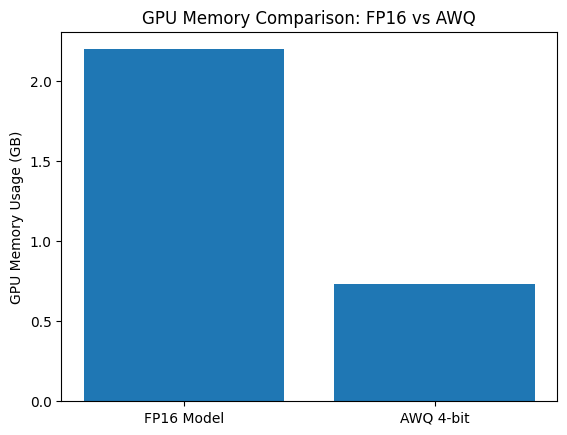

In [13]:
import matplotlib.pyplot as plt

models = ["FP16 Model", "AWQ 4-bit"]
memory = [2.2, 0.73]

plt.bar(models, memory)
plt.ylabel("GPU Memory Usage (GB)")
plt.title("GPU Memory Comparison: FP16 vs AWQ")

plt.show()

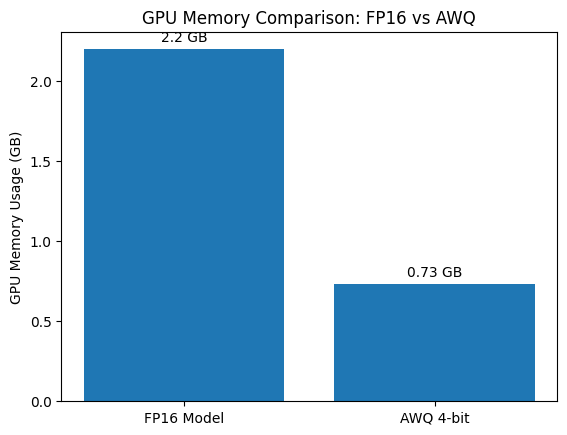

In [14]:
import matplotlib.pyplot as plt

models = ["FP16 Model", "AWQ 4-bit"]
memory = [2.2, 0.73]

plt.bar(models, memory)

plt.ylabel("GPU Memory Usage (GB)")
plt.title("GPU Memory Comparison: FP16 vs AWQ")

for i, v in enumerate(memory):
    plt.text(i, v + 0.05, str(v) + " GB", ha="center")

plt.show()

In [2]:
plt.savefig("awq_memory_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

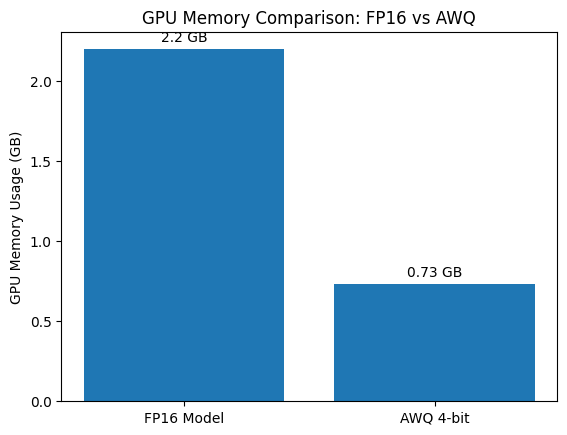

In [1]:
import matplotlib.pyplot as plt

models = ["FP16 Model", "AWQ 4-bit"]
memory = [2.2, 0.73]

plt.bar(models, memory)

plt.ylabel("GPU Memory Usage (GB)")
plt.title("GPU Memory Comparison: FP16 vs AWQ")

for i, v in enumerate(memory):
    plt.text(i, v + 0.05, str(v) + " GB", ha="center")

# Save graph for report/slides
plt.savefig("awq_memory_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

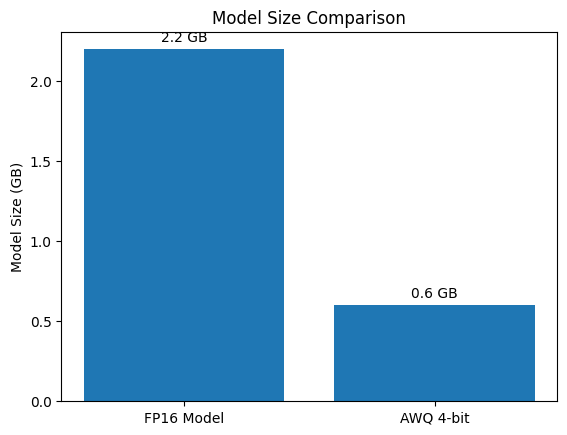

In [3]:
import matplotlib.pyplot as plt

models = ["FP16 Model", "AWQ 4-bit"]
size = [2.2, 0.6]

plt.bar(models, size)

plt.ylabel("Model Size (GB)")
plt.title("Model Size Comparison")

for i, v in enumerate(size):
    plt.text(i, v + 0.05, str(v) + " GB", ha="center")

plt.savefig("awq_model_size.png", dpi=300, bbox_inches="tight")
plt.show()